# Ejercicio 6 — Correlación de NDVI y NDWI con cianobacteria

Este cuaderno calcula correlaciones de Pearson y Spearman por lago y fecha. Solo usa pares de píxeles simultáneamente válidos, alineados en la misma rejilla y contenidos en el contorno real del lago. Los valores *p* se reportan como evidencia exploratoria: los píxeles vecinos no son observaciones independientes.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.correlaciones import validate_inputs, run_correlations

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

## 1. Validación y ejecución reproducible

In [2]:
validation = validate_inputs()
results = run_correlations()
validation

{'filas_manifest': 66, 'rasters': 66, 'escenas': 22}

## 2. Resumen por lago

In [3]:
by_lake = pd.DataFrame(results["by_lake"])
by_lake[[
    "lago", "indice", "metodo", "n_fechas", "coeficiente_mediano_fechas",
    "coeficiente_agrupado_estratificado", "n_pares_agrupado", "magnitud_agrupada"
]]

,lago,indice,metodo,n_fechas,coeficiente_mediano_fechas,coeficiente_agrupado_estratificado,n_pares_agrupado,magnitud_agrupada
0,amatitlan,ndvi,pearson,11,0.666816,0.236880,110000,debil
1,amatitlan,ndvi,spearman,11,0.632964,0.608965,110000,fuerte
2,amatitlan,ndwi,pearson,11,-0.591857,-0.349950,110000,moderada
3,amatitlan,ndwi,spearman,11,-0.505574,-0.374277,110000,moderada
4,atitlan,ndvi,pearson,11,0.028163,-0.019558,110000,muy_debil
5,atitlan,ndvi,spearman,11,0.127319,-0.067656,110000,muy_debil
6,atitlan,ndwi,pearson,11,-0.000049,-0.061480,110000,muy_debil
7,atitlan,ndwi,spearman,11,-0.069031,-0.534887,110000,fuerte


El resumen principal es la mediana de los 11 coeficientes por fecha. La correlación agrupada usa como máximo 10,000 pares por fecha para que ninguna escena domine por tamaño, pero no sustituye la evidencia fecha a fecha.

## 3. Variación de los coeficientes por fecha

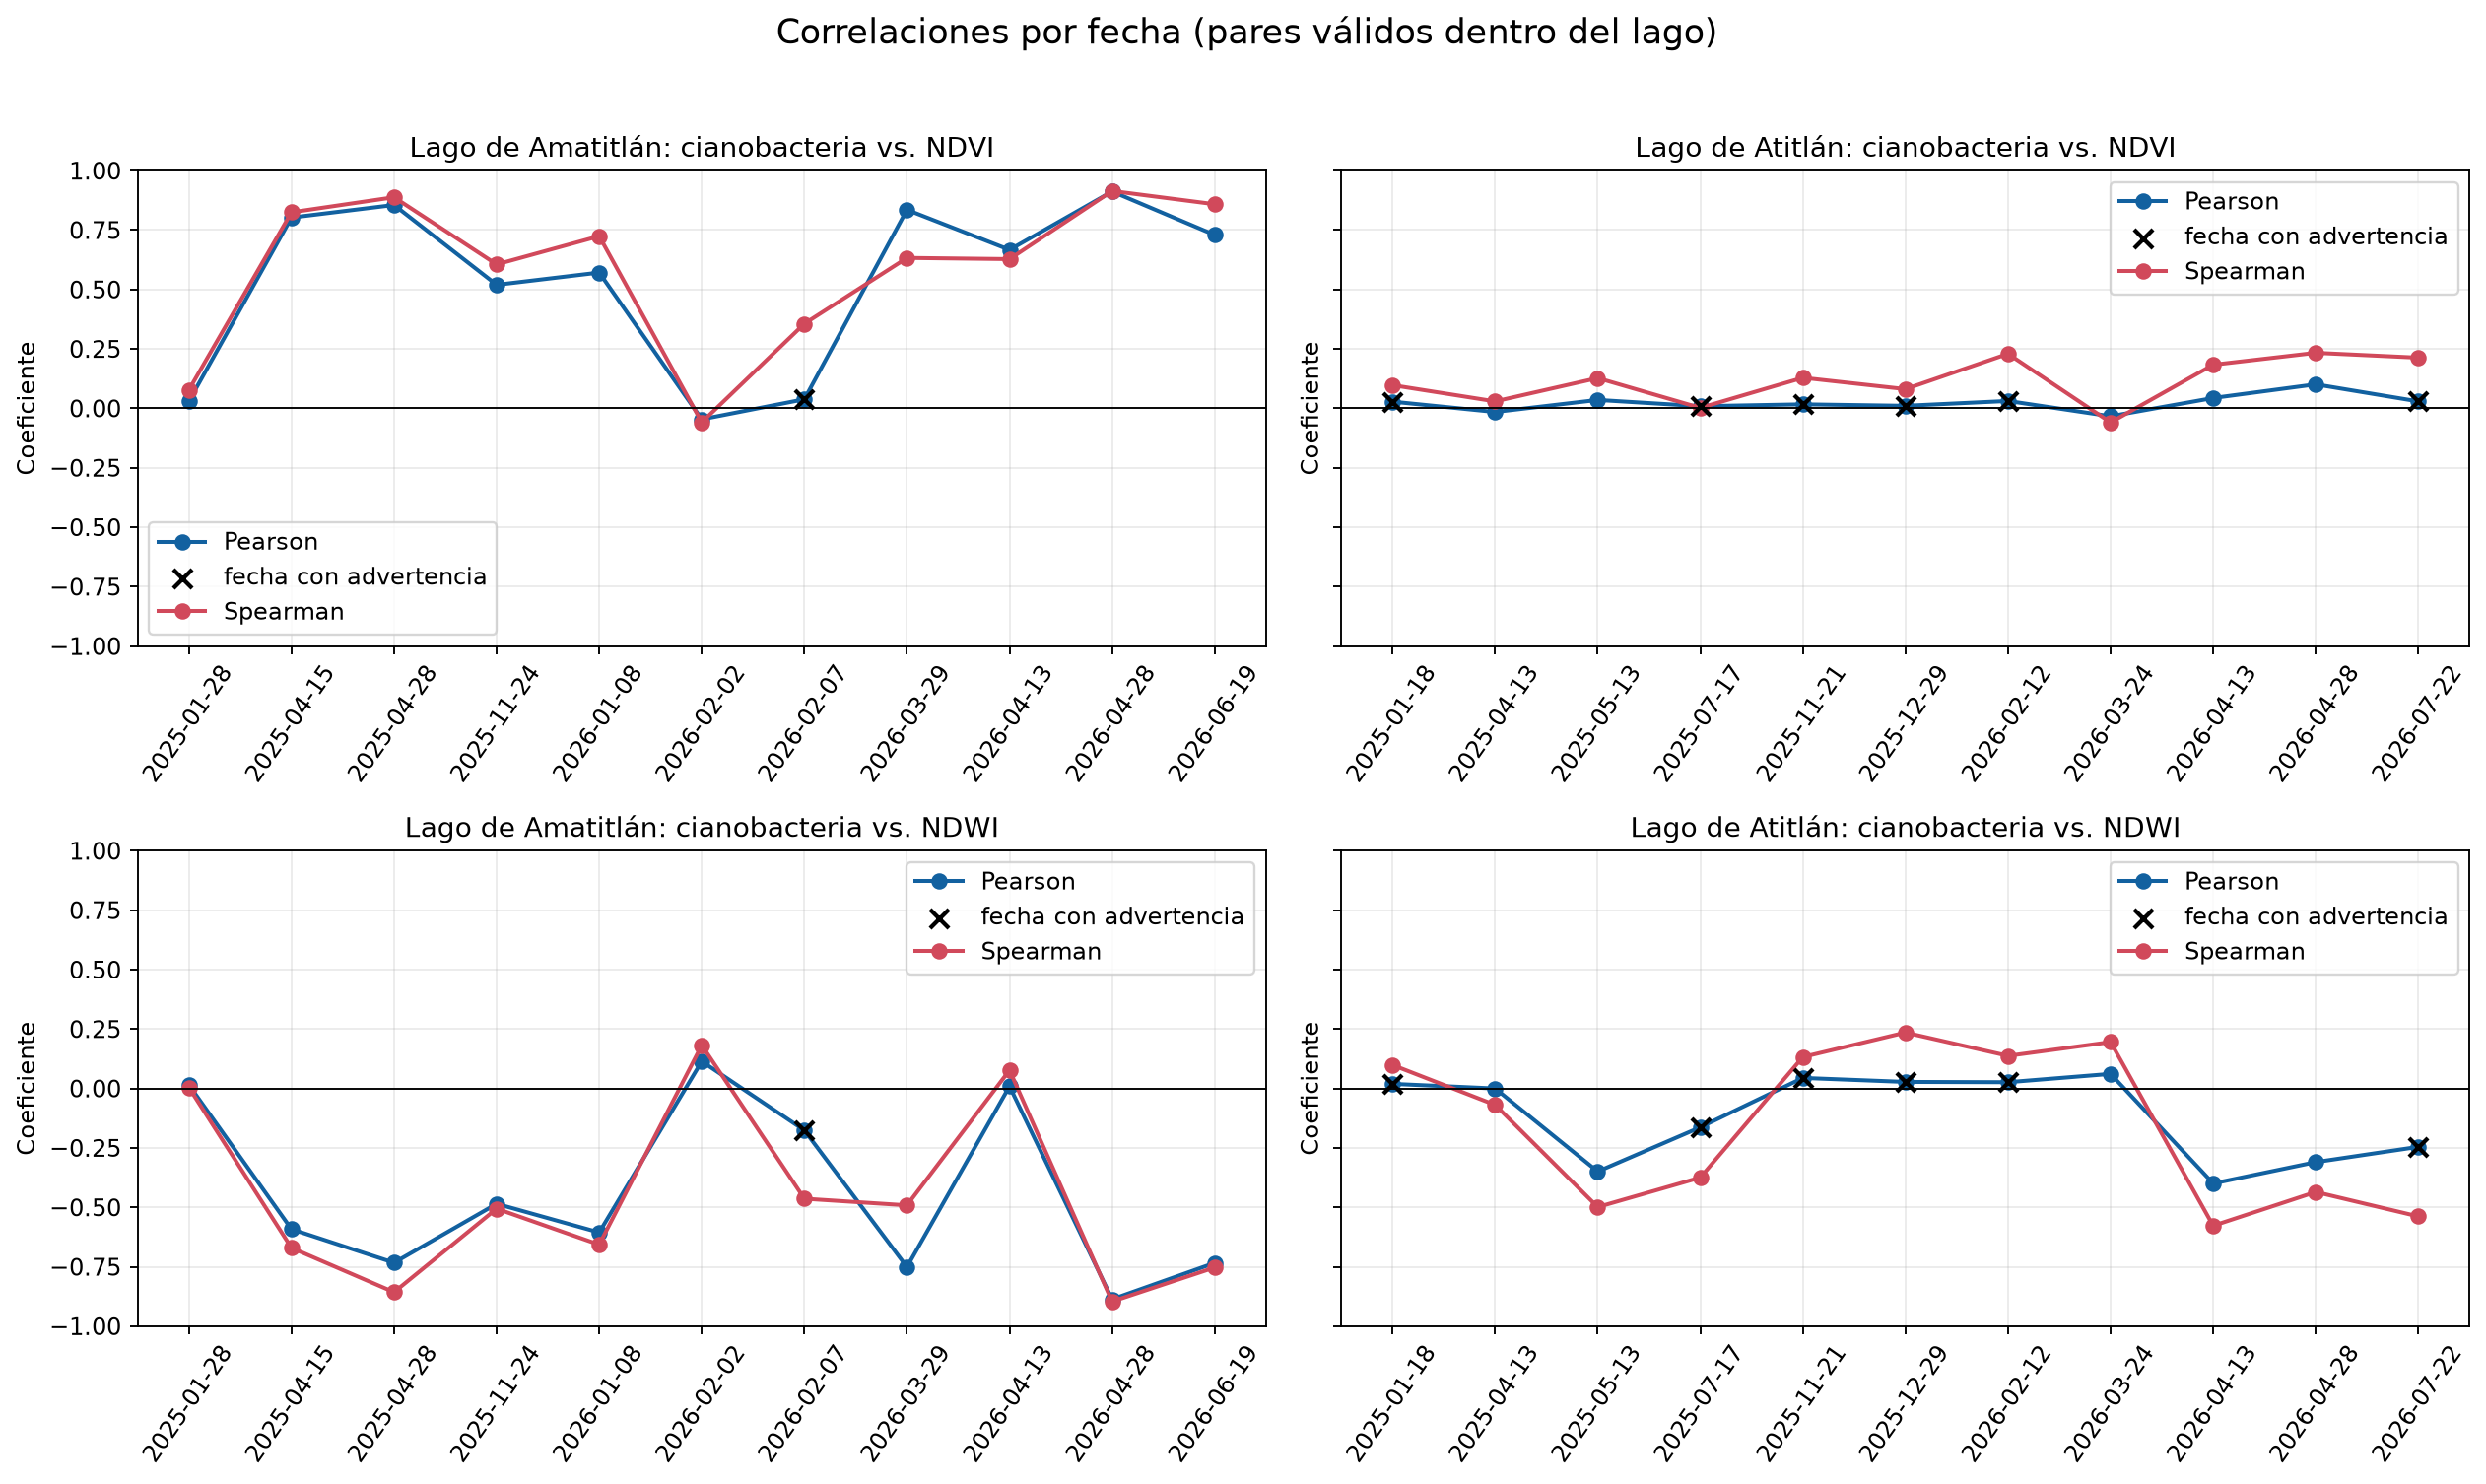

In [4]:
display(Image(filename=str(ROOT / "results/figures/correlaciones_por_fecha.png")))

In [5]:
by_date = pd.DataFrame(results["by_date"])
by_date.assign(abs_coef=lambda frame: frame["coeficiente"].abs()).sort_values(
    "abs_coef", ascending=False
)[[
    "lago", "fecha", "indice", "metodo", "coeficiente", "n_pares",
    "quality_flag_cianobacteria", "quality_flag_indice"
]].head(12)

,lago,fecha,indice,metodo,coeficiente,n_pares,quality_flag_cianobacteria,quality_flag_indice
37,amatitlan,2026-04-28,ndvi,spearman,0.914463,129097,calculado,calculado
36,amatitlan,2026-04-28,ndvi,pearson,0.912445,129097,calculado,calculado
39,amatitlan,2026-04-28,ndwi,spearman,-0.896176,129097,calculado,calculado
9,amatitlan,2025-04-28,ndvi,spearman,0.888089,139812,calculado,calculado
38,amatitlan,2026-04-28,ndwi,pearson,-0.886838,129097,calculado,calculado
41,amatitlan,2026-06-19,ndvi,spearman,0.858795,141050,calculado,calculado
11,amatitlan,2025-04-28,ndwi,spearman,-0.856987,139812,calculado,calculado
8,amatitlan,2025-04-28,ndvi,pearson,0.855531,139812,calculado,calculado
28,amatitlan,2026-03-29,ndvi,pearson,0.835299,140681,calculado,calculado
5,amatitlan,2025-04-15,ndvi,spearman,0.824764,139503,calculado,calculado


## 4. Forma de las relaciones

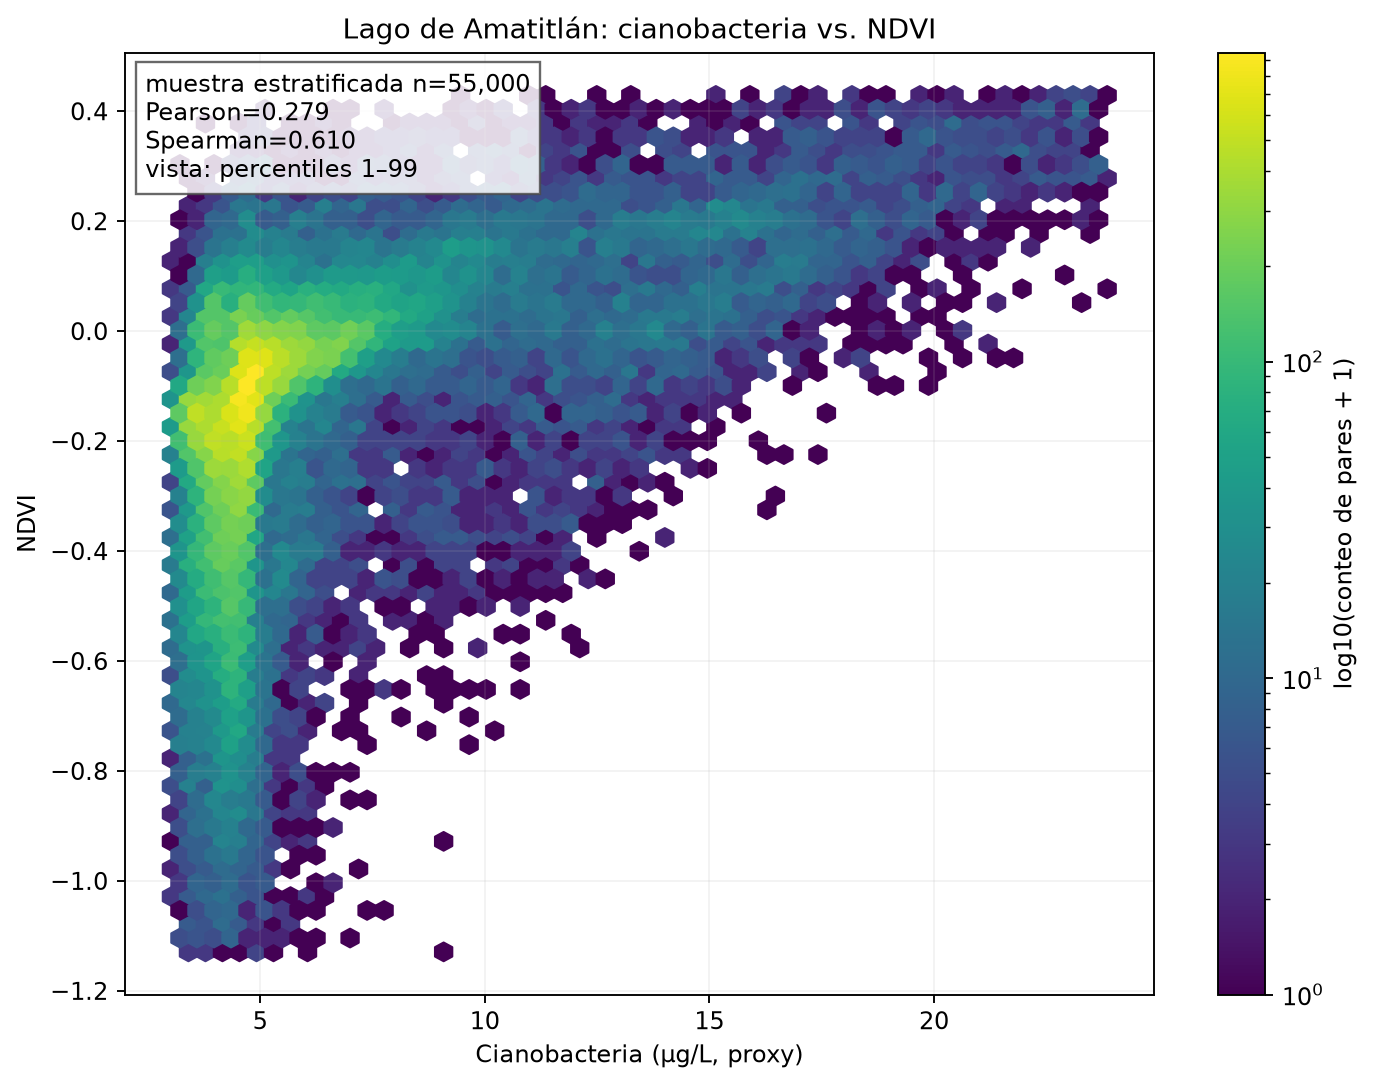

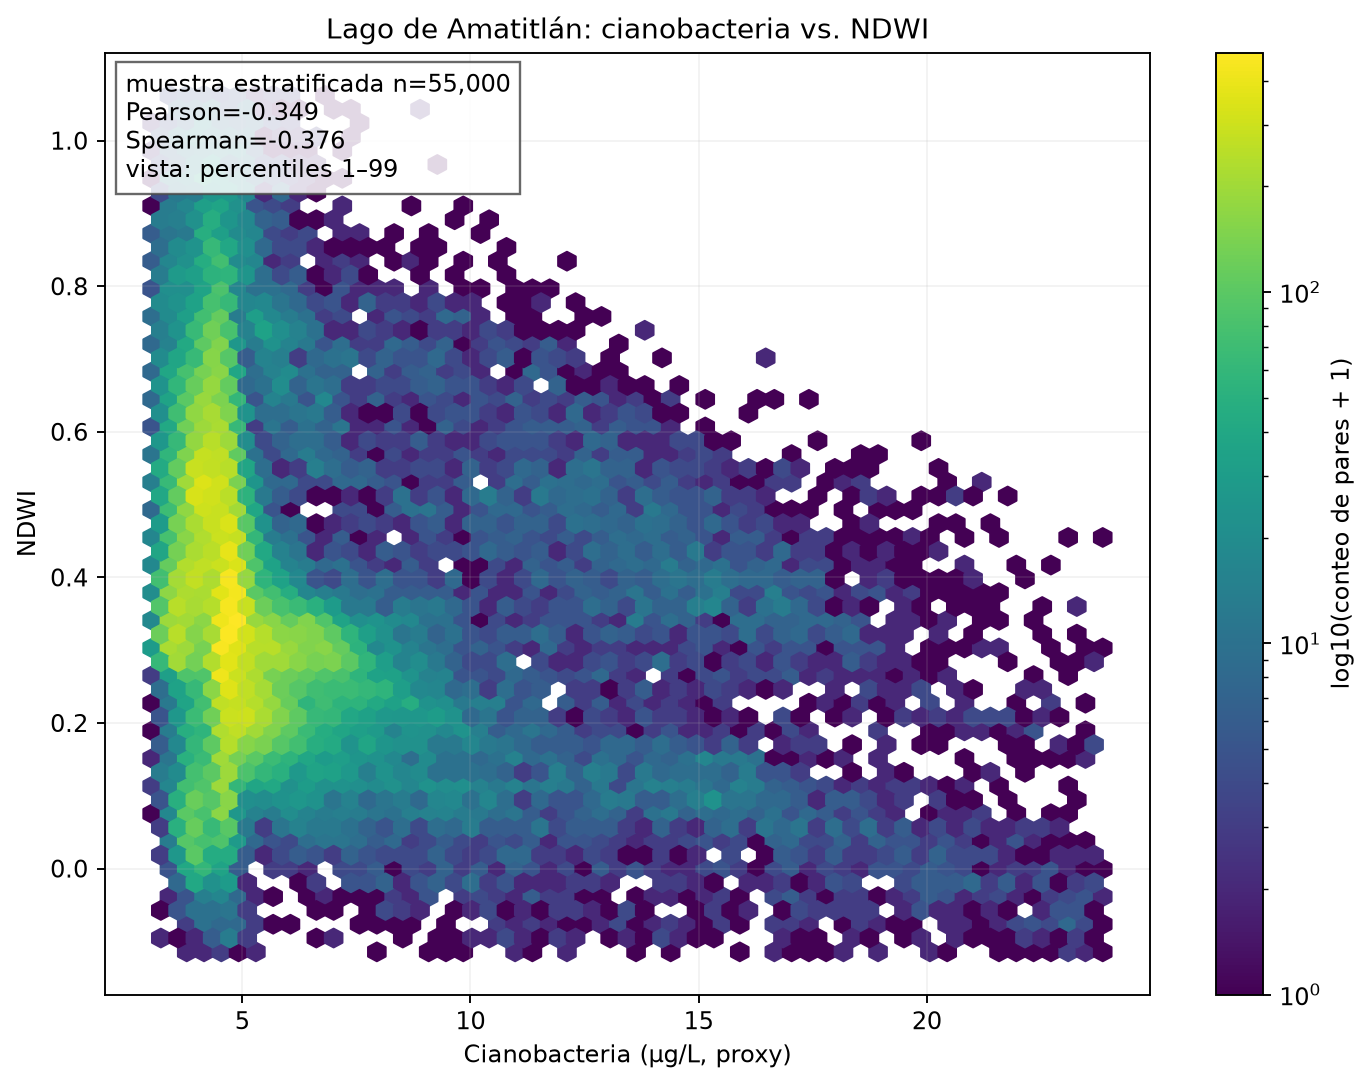

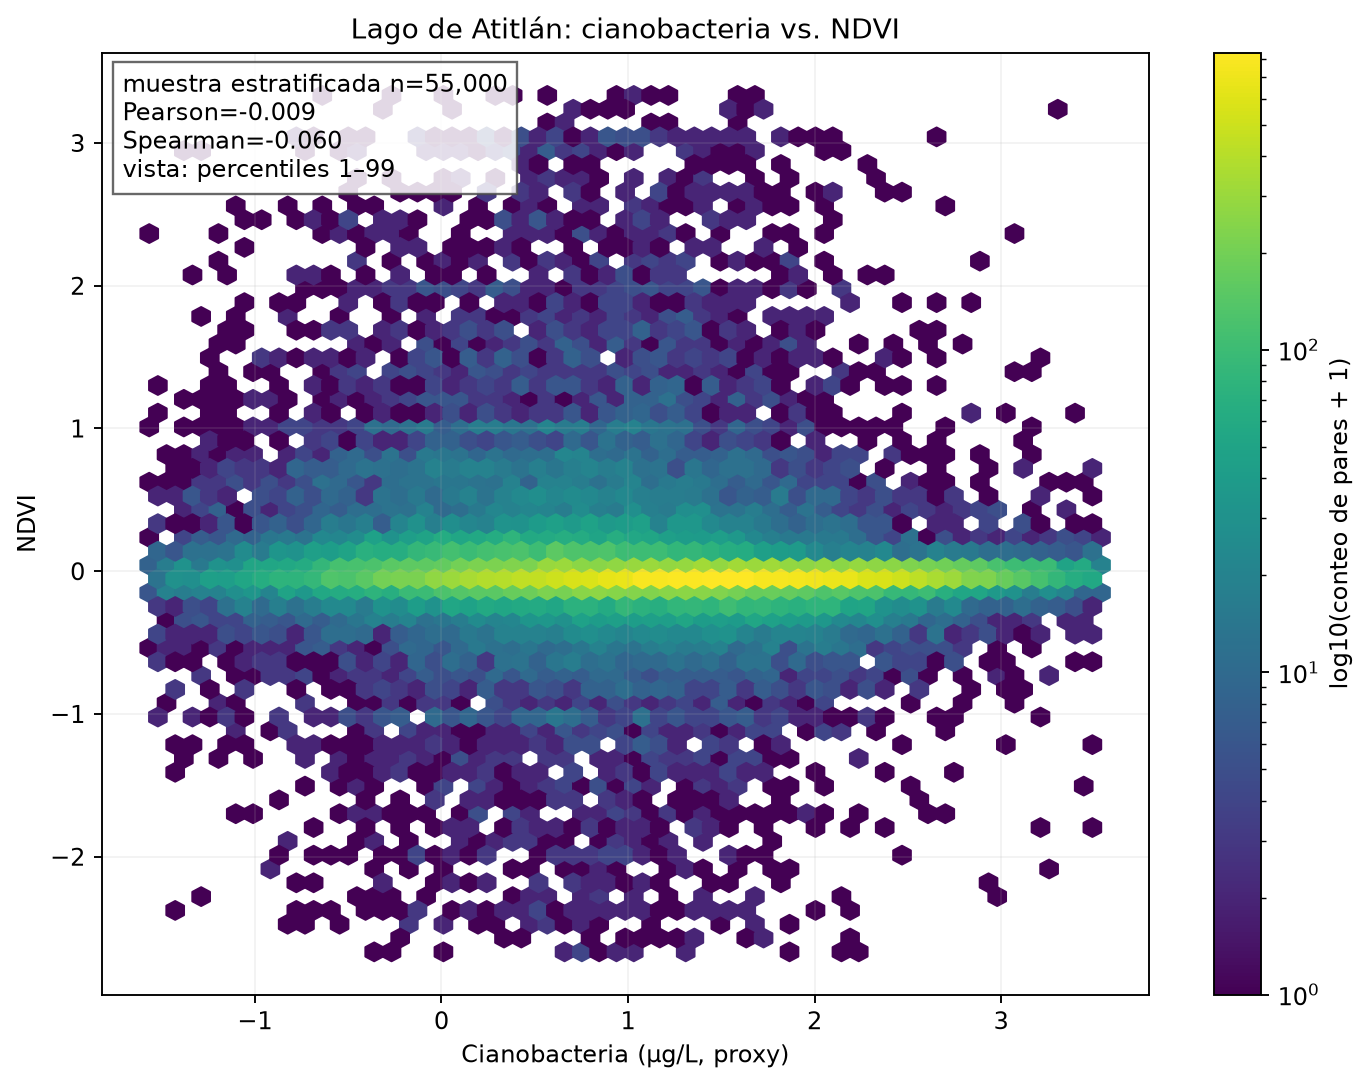

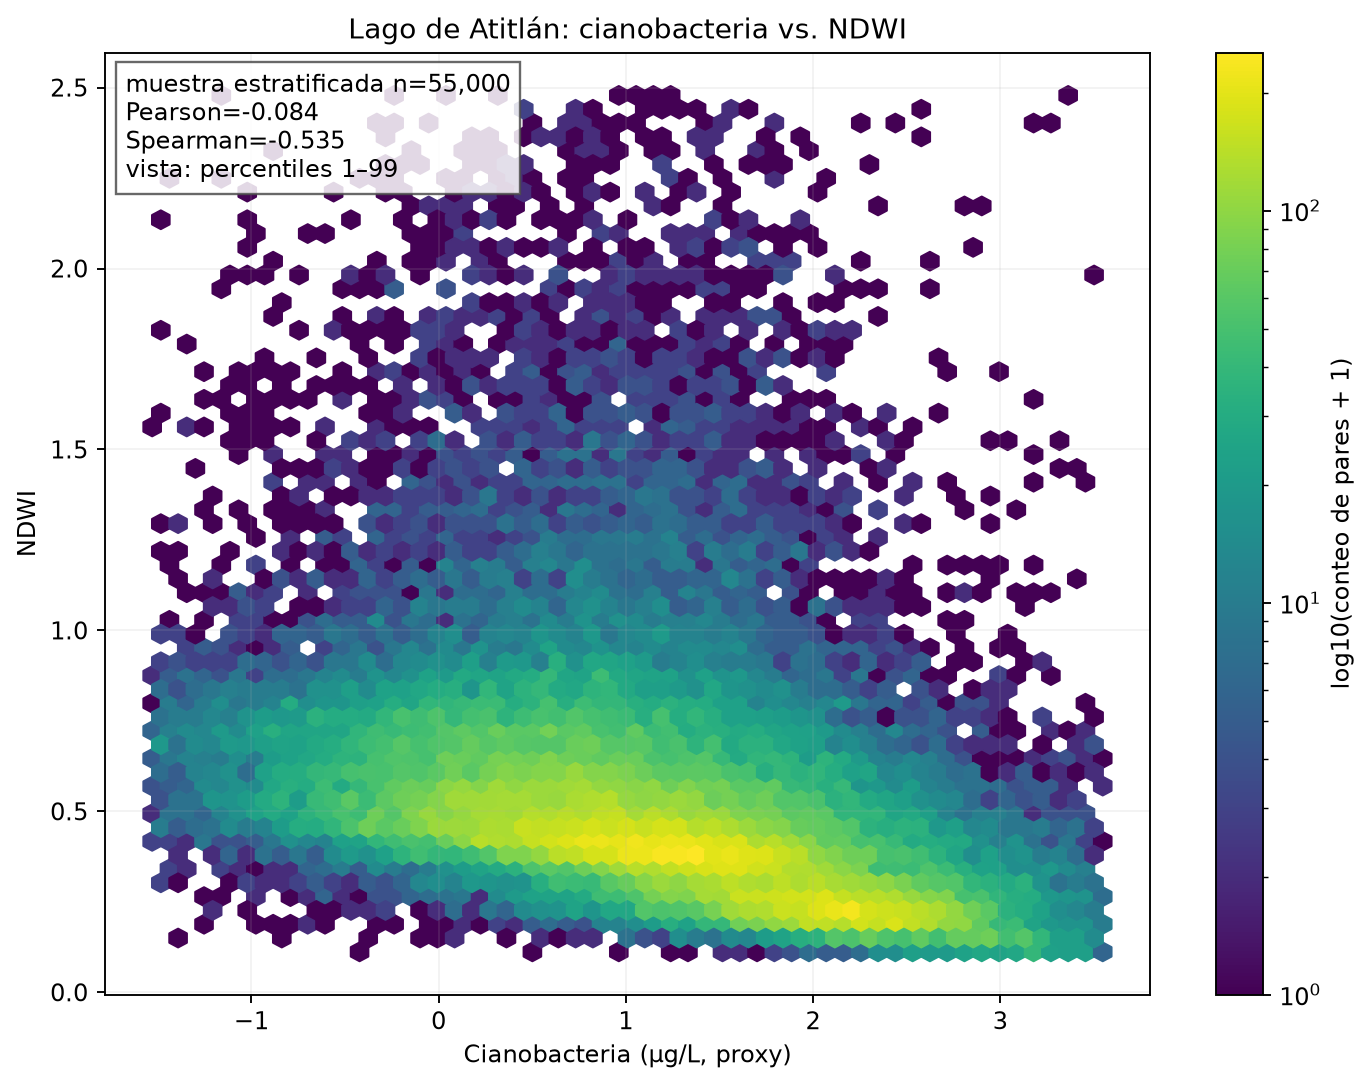

In [6]:
for lake in ("amatitlan", "atitlan"):
    for index in ("ndvi", "ndwi"):
        display(Image(filename=str(ROOT / f"results/figures/{lake}_cianobacteria_{index}_hexbin.png")))

## 5. Hallazgos

- **Amatitlán — NDVI:** la mediana por fecha es positiva y de magnitud fuerte (Pearson ≈ 0.667; Spearman ≈ 0.633). Diez de once fechas tienen signo positivo. La diferencia entre Pearson agrupado (≈ 0.237) y Spearman agrupado (≈ 0.609) indica una relación monotónica no puramente lineal y sensible a la mezcla de fechas.
- **Amatitlán — NDWI:** predomina una relación negativa (medianas por fecha Pearson ≈ −0.592 y Spearman ≈ −0.506). Valores más altos del proxy de cianobacteria aparecen, en general, junto a NDWI más bajo dentro de los píxeles comparables.
- **Atitlán — NDVI:** las medianas por fecha son muy débiles (Pearson ≈ 0.028; Spearman ≈ 0.127), por lo que no hay una asociación consistente de importancia práctica.
- **Atitlán — NDWI:** los coeficientes por fecha cambian de signo y sus medianas están cerca de cero. Aunque Spearman agrupado es aproximadamente −0.535, no se interpreta como una relación estable: surge al mezclar fechas con distribuciones distintas, mientras la evidencia por fecha es débil y variable.

Estas asociaciones no demuestran causalidad. La significancia numérica puede ser muy pequeña por el enorme número de píxeles, pero la autocorrelación espacial reduce la independencia efectiva de la muestra; por eso se interpreta primero magnitud, consistencia entre fechas y forma de la relación.

## Productos

- `results/tables/correlaciones_por_fecha.csv`
- `results/tables/correlaciones_por_lago.csv`
- `results/figures/correlaciones_por_fecha.png`
- cuatro diagramas hexbin en `results/figures/`

Todos los coeficientes conservan lago, fecha, método, número de pares y banderas de calidad.